In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import ttest_ind, norm
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import TTestIndPower, NormalIndPower

In [2]:
df = pd.read_csv("TXC_25_landingpage.csv")
print(df['arm'].value_counts())

df

arm
control      1308
treatment    1301
pre          1088
Name: count, dtype: int64


,group_id,arm,visitor_id,arrival_time,exit_time,time_on_page_sec,exit_rate,ctr_opportunities,ctr_newsletter,ctr_donation,ctr_events,kpi_x,kpi_y,scroll_depth_pct,ctr_partner_banner,page_load_time_ms
0,TXC_25,treatment,2497,2026-02-22 12:41:07,2026-02-22 12:45:05.9,238.9,0,0,0,0,0,23.380,0,95.50,0,7105.8
1,TXC_25,control,2258,2026-02-22 13:00:26,2026-02-22 13:01:10,44.0,0,0,0,0,0,0.642,0,2.16,0,1719.3
2,TXC_25,control,1474,2026-02-22 13:47:04,2026-02-22 13:50:53.8,229.8,0,1,0,0,0,20.892,0,36.72,0,6193.4
3,TXC_25,treatment,2708,2026-02-22 15:01:01,2026-02-22 15:01:05.2,4.2,1,0,0,0,0,0.360,0,8.20,0,2293.9
4,TXC_25,pre,477,2026-02-22 15:15:46,2026-02-22 15:16:40.9,54.9,0,0,0,0,0,96.350,0,16.90,0,1779.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3692,TXC_25,pre,970,2026-03-06 15:12:46,2026-03-06 15:13:26.1,40.1,0,0,0,0,0,75.660,0,5.90,1,4193.2
3693,TXC_25,pre,181,2026-03-06 15:17:21,2026-03-06 15:18:02.6,41.6,0,0,0,0,0,38.370,0,4.00,0,1504.6
3694,TXC_25,control,1801,2026-03-06 15:38:44,2026-03-06 15:38:57.8,13.8,0,0,0,0,1,49.824,0,57.66,0,1469.3
3695,TXC_25,pre,374,2026-03-06 16:42:18,2026-03-06 16:42:18.9,0.9,1,0,0,0,0,3.310,0,7.90,0,1466.9


In [3]:
# Data cleaning
df_pre   = df[df['arm'] == 'pre'].copy()
df_exp   = df[df['arm'].isin(['control', 'treatment'])].copy()

ctr_donate = "ctr_donation"
dwell_time = "time_on_page_sec"

# Check for exact duplicates
n_dupes = df_exp.duplicated().sum()
print(f'Exact duplicate rows: {n_dupes}')

# drop unused columns
df_exp = df_exp.drop(columns=["visitor_id", "group_id", 'kpi_x', 'kpi_y', 'exit_time', 'ctr_events', 'ctr_newsletter', 'ctr_opportunities', 'ctr_partner_banner', 'exit_rate'])

# negative or zero dwell time
mask_neg = df_exp[dwell_time] <= 0
print(f'Rows with dwell ≤ 0: {mask_neg.sum()}')

# non binary ctr-donation entries
non_binary_count = (~df_exp[ctr_donate].isin([0, 1])).sum()
print(f"CTR donation non-binary: {non_binary_count}")

# negative or zero page load time
bad_load = df_exp['page_load_time_ms'] <= 0
print(f"Rows with negative or zero page_load_time: {bad_load.sum()}")

# negative scroll depth percentage
bad_scroll = df_exp['scroll_depth_pct'] < 0
print(f"Rows with negative scroll depth percentage: {bad_scroll.sum()}")

# guarantee arrival time is datetime object
df_exp['arrival_time'] = pd.to_datetime(df_exp['arrival_time'], format='mixed', errors='coerce')

df_exp

Exact duplicate rows: 0
Rows with dwell ≤ 0: 0
CTR donation non-binary: 0
Rows with negative or zero page_load_time: 0
Rows with negative scroll depth percentage: 0


,arm,arrival_time,time_on_page_sec,ctr_donation,scroll_depth_pct,page_load_time_ms
0,treatment,2026-02-22 12:41:07,238.9,0,95.50,7105.8
1,control,2026-02-22 13:00:26,44.0,0,2.16,1719.3
2,control,2026-02-22 13:47:04,229.8,0,36.72,6193.4
3,treatment,2026-02-22 15:01:01,4.2,0,8.20,2293.9
5,treatment,2026-02-22 15:57:59,48.5,0,100.00,910.2
...,...,...,...,...,...,...
3687,treatment,2026-03-06 10:17:12,15.3,0,83.50,1822.6
3690,control,2026-03-06 14:35:31,192.9,0,1.70,1611.7
3691,treatment,2026-03-06 15:00:18,17.0,0,18.80,1815.8
3694,control,2026-03-06 15:38:44,13.8,0,57.66,1469.3


In [4]:
# Outlier analysis
# checking for dwell time extreme outliers
q1 = df_exp[dwell_time].quantile(0.25)
q3 = df_exp[dwell_time].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 3 * iqr

print(f'IQR = {iqr:.1f} sec')
print(f'Upper Tukey fence (3 x IQR): {upper_fence:.1f} sec')

# Add time out limit (30 minutes is regarded as open tab or similar)
CAP_SECONDS = 1800

# create outlier flags
df_exp['outlier_tukey'] = df_exp[dwell_time] > upper_fence
df_exp['outlier_cap'] = df_exp[dwell_time] > CAP_SECONDS

print(f'Outliers above Tukey fence: {df_exp["outlier_tukey"].sum()}')
print(f'Outliers above 30 min cap: {df_exp["outlier_cap"].sum()}')

# winsorize dwell time for main analysis
upper = df_exp[dwell_time].quantile(0.99)
print(f'99th percentile cap: {upper:.1f} sec')
df_exp[dwell_time] = df_exp[dwell_time].clip(upper=upper)

# balance check
print('\nOutlier balance by arm:')
print(df_exp.groupby('arm')['outlier_tukey'].sum())

IQR = 147.8 sec
Upper Tukey fence (3 x IQR): 602.1 sec
Outliers above Tukey fence: 179
Outliers above 30 min cap: 117
99th percentile cap: 6071.3 sec

Outlier balance by arm:
arm
control      88
treatment    91
Name: outlier_tukey, dtype: int64


In [5]:
# Sample Ratio Mismatch test: are the two arms equal-sized as designed?
arm_counts = df_exp['arm'].value_counts()
expected = np.array([len(df_exp) / 2, len(df_exp) / 2])
observed = arm_counts[['control', 'treatment']].values
chi2_srm, p_srm = stats.chisquare(observed, expected)
print(f'SRM chi-square = {chi2_srm:.4f}, p = {p_srm:.4f}')

SRM chi-square = 0.0188, p = 0.8910


In [6]:
# covariate balance of guardrails between arms
covariates = ['scroll_depth_pct', 'page_load_time_ms']
balance = df_exp.groupby('arm')[covariates].mean().T
print('Mean covariate values by arm:')
print(balance.round(2))

# t-tests for balance
print('\nBalance t-tests (control vs treatment):')
ctrl = df_exp[df_exp['arm'] == 'control']
trt = df_exp[df_exp['arm'] == 'treatment']
for cov in covariates:
    t, p = ttest_ind(ctrl[cov], trt[cov])
    print(f'  {cov:25s}  t={t:6.3f}  p={p:.3f}')

Mean covariate values by arm:
arm                control  treatment
scroll_depth_pct     22.35      41.71
page_load_time_ms  2036.87    2123.81

Balance t-tests (control vs treatment):
  scroll_depth_pct           t=-17.634  p=0.000
  page_load_time_ms          t=-1.108  p=0.268


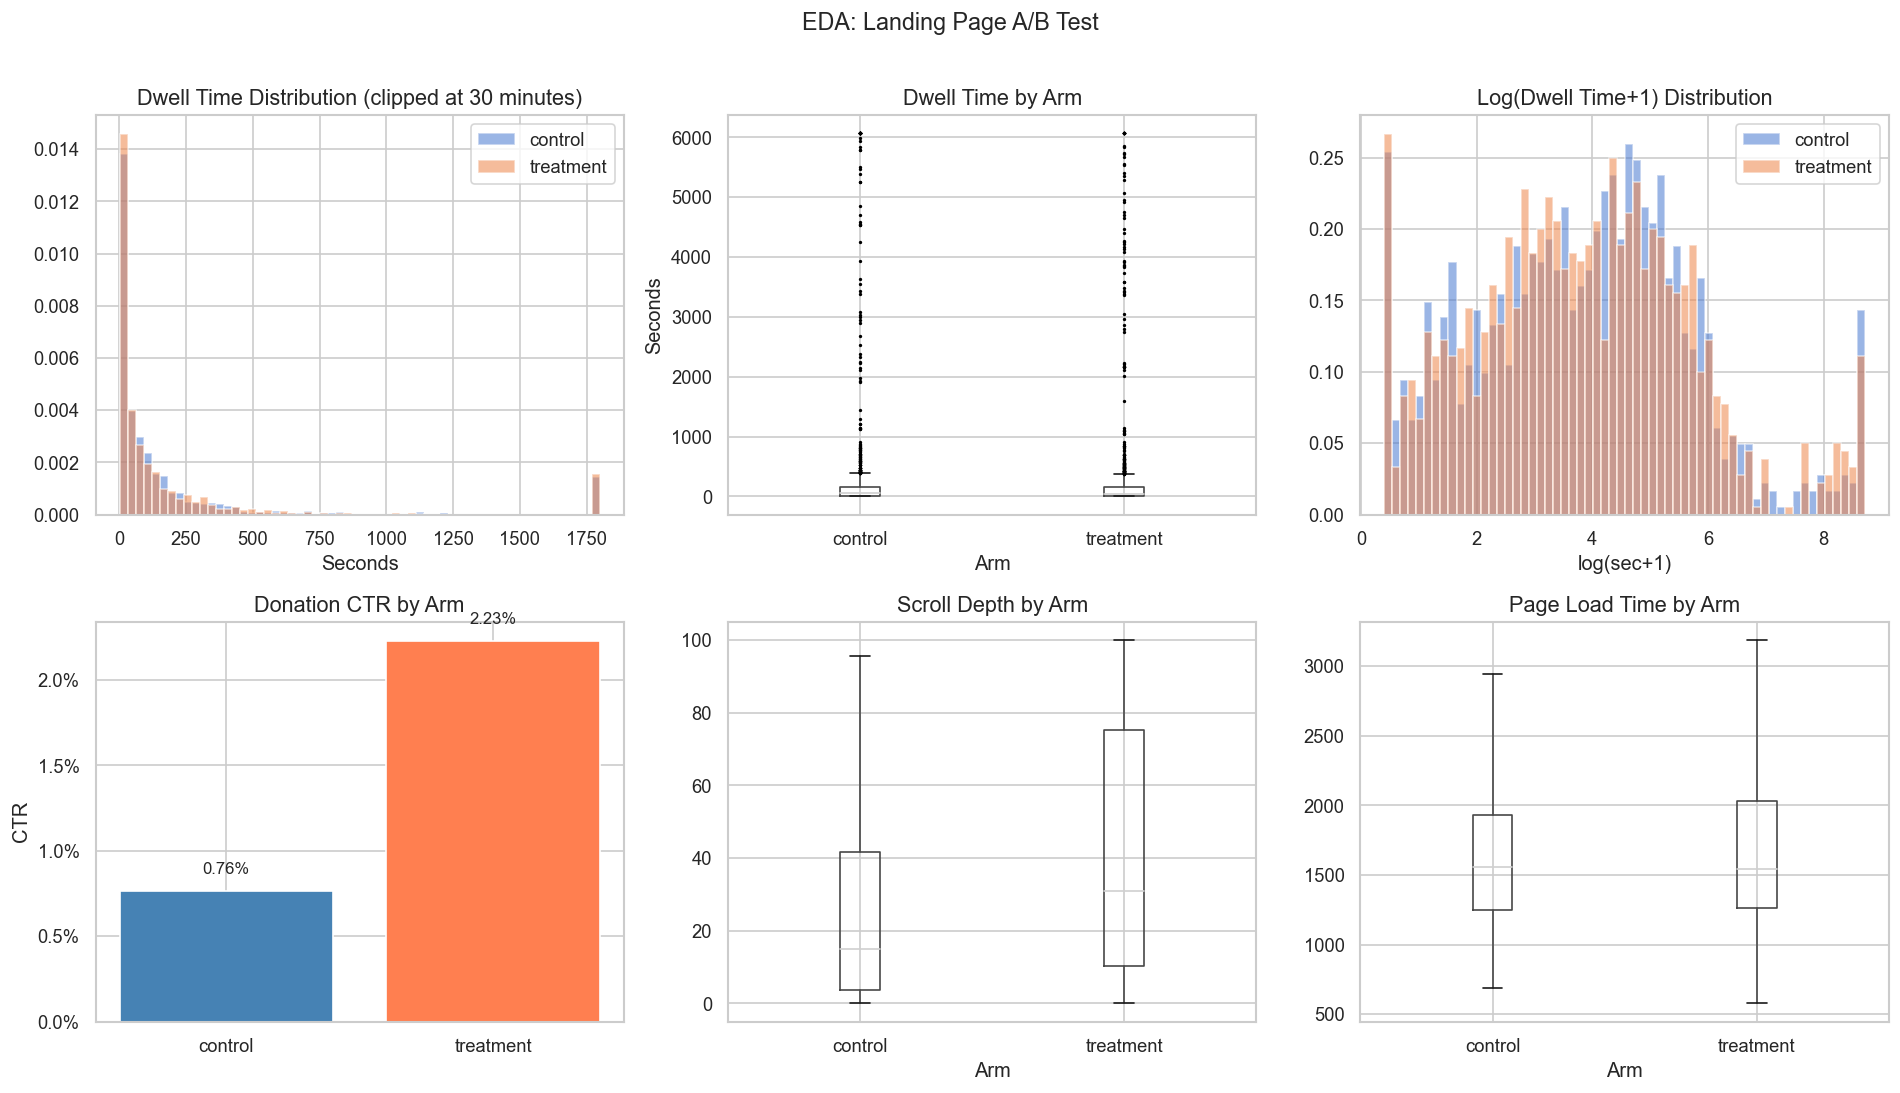

In [7]:
# Visualizations
# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Dwell time distributions
for arm, grp in df_exp.groupby('arm'):
    axes[0,0].hist(grp[dwell_time].clip(upper=1800), bins=60,
                   alpha=0.55, label=arm, density=True)
axes[0,0].set_title('Dwell Time Distribution (clipped at 30 minutes)')
axes[0,0].set_xlabel('Seconds')
axes[0,0].legend()

# Box plots dwell time
df_exp.boxplot(column=dwell_time, by='arm', ax=axes[0,1],
               showfliers=True, flierprops=dict(marker='.', markersize=2))
axes[0,1].set_title('Dwell Time by Arm')
axes[0,1].set_xlabel('Arm')
axes[0,1].set_ylabel('Seconds')
plt.sca(axes[0,1]); plt.title('Dwell Time by Arm')

# Log dwell time
df_exp['dwell_log'] = np.log1p(df_exp[dwell_time])
for arm, grp in df_exp.groupby('arm'):
    axes[0,2].hist(grp['dwell_log'], bins=60, alpha=0.55, label=arm, density=True)
axes[0,2].set_title('Log(Dwell Time+1) Distribution')
axes[0,2].set_xlabel('log(sec+1)')
axes[0,2].legend()

# CTR bar chart
ctr_by_arm = df_exp.groupby('arm')[ctr_donate].mean().reset_index()
axes[1,0].bar(ctr_by_arm['arm'], ctr_by_arm[ctr_donate], color=['steelblue','coral'])
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
axes[1,0].set_title('Donation CTR by Arm')
axes[1,0].set_ylabel('CTR')
for i, row in ctr_by_arm.iterrows():
    axes[1,0].text(i, row[ctr_donate] + 0.001, f"{row[ctr_donate]:.2%}",
                   ha='center', fontsize=10)

# Scroll depth by arm
df_exp.boxplot(column='scroll_depth_pct', by='arm', ax=axes[1,1],
               showfliers=False)
axes[1,1].set_title('Scroll Depth by Arm')
axes[1,1].set_xlabel('Arm')
plt.sca(axes[1,1]); plt.title('Scroll Depth by Arm')

# Page load time by arm
df_exp.boxplot(column='page_load_time_ms', by='arm', ax=axes[1,2],
               showfliers=False)
axes[1,2].set_title('Page Load Time by Arm')
axes[1,2].set_xlabel('Arm')
plt.sca(axes[1,2]); plt.title('Page Load Time by Arm')

fig.suptitle('EDA: Landing Page A/B Test', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# error pattern diagnostic
# Very short sessions (less than 1 second) tend to be bots or similar
n_bots = (df_exp[dwell_time] < 1).sum()
pct_bots = n_bots / len(df_exp) * 100
print(f'Sessions < 1 sec:  {n_bots}  ({pct_bots:.1f}%)')
bots_by_arm = df_exp[df_exp[dwell_time] < 1]['arm'].value_counts()
print(bots_by_arm)

# Page load time outliers could influence dwell time
p95_load = df_exp['page_load_time_ms'].quantile(0.95)
n_slow_load = (df_exp['page_load_time_ms'] > p95_load).sum()
print(f'\nSessions with high page load ( > 95th pct: {p95_load:.0f} ms):  {n_slow_load}')
slow_load_by_arm = df_exp[df_exp['page_load_time_ms'] > p95_load]['arm'].value_counts()
print(slow_load_by_arm)

# were arms exposed at the same times?
df_exp['hour_of_day'] = df_exp['arrival_time'].dt.hour
hour_balance = df_exp.groupby(['arm', 'hour_of_day']).size().unstack(fill_value=0)
print('\nHourly traffic balance:')
print(hour_balance.T)

Sessions < 1 sec:  112  (4.3%)
arm
control      58
treatment    54
Name: count, dtype: int64

Sessions with high page load ( > 95th pct: 5374 ms):  131
arm
treatment    74
control      57
Name: count, dtype: int64

Hourly traffic balance:
arm          control  treatment
hour_of_day                    
0                 14          8
1                  7          3
2                  3          4
3                 41         33
4                  3          3
5                  3          2
6                  8          6
7                 36         18
8                 52         30
9                 90         99
10               131         94
11               114         83
12                64         66
13                59         79
14                72         99
15               109        106
16                84         73
17                56         65
18                53         78
19                65        107
20                91        122
21                83     

In [9]:
# Power calculation — CTR
# parameters based on pre-period baseline
baseline_ctr = df_pre[ctr_donate].mean()
print(f'Pre-period baseline donation CTR: {baseline_ctr:.4f}')

# minimum detectable effect assume we care about a 1% lift
mde_ctr = 0.01

p0 = baseline_ctr
p1 = p0 + mde_ctr

alpha = 0.05
power_target = 0.80

# Two-proportion z-test sample size
effect_size_ctr = proportion_effectsize(p1, p0)
analysis_ctr = NormalIndPower()
n_required_ctr = analysis_ctr.solve_power(effect_size=effect_size_ctr,
                                             alpha=alpha,
                                             power=power_target,
                                             alternative='two-sided')

actual_power_ctr = analysis_ctr.solve_power(effect_size=effect_size_ctr,
                                              alpha=alpha,
                                              nobs1=len(ctrl),
                                              alternative='two-sided')
                                             
print(f'Baseline CTR (p0) = {p0:.4f}')
print(f'Target CTR (p1) (incl. MDE) = {p1:.4f}')
print(f'MDE = {mde_ctr:.3f} ({mde_ctr/p0*100:.0f}% relativ increase)')
print(f'Effect size (Cohen h) = {effect_size_ctr:.4f}') # check ich nicht
print(f'Required N per arm = {int(np.ceil(n_required_ctr))}')
print(f'Actual N per arm = {len(ctrl):,}')
print(f'Achieved power (at actual N) = {actual_power_ctr:.3f}')

Pre-period baseline donation CTR: 0.0156
Baseline CTR (p0) = 0.0156
Target CTR (p1) (incl. MDE) = 0.0256
MDE = 0.010 (64% relativ increase)
Effect size (Cohen h) = 0.0709
Required N per arm = 3125
Actual N per arm = 1,308
Achieved power (at actual N) = 0.442


In [10]:
# Descriptive analysis CTR
ctrl = df_exp[df_exp['arm'] == 'control']

ctrl_ctr = df_exp[df_exp['arm'] == 'control'][ctr_donate]
trt_ctr = df_exp[df_exp['arm'] == 'treatment'][ctr_donate]

n_ctrl_tot = len(ctrl_ctr)
n_trt_tot = len(trt_ctr)
n_ctrl_don = ctrl_ctr.sum()
n_trt_don = trt_ctr.sum()
p_ctrl = ctrl_ctr.mean()
p_trt = trt_ctr.mean()
diff = p_trt - p_ctrl

z = norm.ppf(1 - alpha/2)

# 95% confidence interavl for the difference between control and treatment ctr
se_diff = np.sqrt(p_ctrl*(1-p_ctrl)/n_ctrl_tot + p_trt*(1-p_trt)/n_trt_tot)
ci_low = diff - z * se_diff
ci_high = diff + z * se_diff

print(f'Control: {n_ctrl_don}/{n_ctrl_tot} = {p_ctrl:.4f} ({p_ctrl*100:.2f}%)')
print(f'Treatment: {n_trt_don}/{n_trt_tot}  = {p_trt:.4f} ({p_trt*100:.2f}%)')
print(f'Absolute difference: {(diff)*100:+.2f} pp')
print(f'Relative difference: {(diff)/p_ctrl*100:+.1f}%')
print(f'95% CI for difference: [{ci_low*100:.3f} pp, {ci_high*100:.3f} pp]')

Control: 10/1308 = 0.0076 (0.76%)
Treatment: 29/1301  = 0.0223 (2.23%)
Absolute difference: +1.46 pp
Relative difference: +191.6%
95% CI for difference: [0.534 pp, 2.395 pp]


In [11]:
# Power calculation Dwell Time
baseline_dw = df_pre[dwell_time].mean()
sd_dwell = df_pre[dwell_time].std()
print(f'Pre-period baseline dwell time: {baseline_dw:.2f} sec, standard deviation {sd_dwell:.2f}')

# assume we care about a 100 sec increase
mde_dwell = 100
mu0 = baseline_dw
mu1 = mu0 + mde_dwell

effect_size_dwell = mde_dwell / sd_dwell

analysis_dwell = TTestIndPower()

n_required_dwell = analysis_dwell.solve_power(
    effect_size=effect_size_dwell,
    alpha=alpha,
    power=power_target,
    alternative='two-sided'
)

actual_power_dwell = analysis_dwell.solve_power(
    effect_size=effect_size_dwell,
    alpha=alpha,
    nobs1=len(ctrl),
    alternative='two-sided'
)

print(f'Baseline dwell time (mu0) = {mu0:.2f} sec')
print(f'Target dwell time (mu1) (incl. MDE) = {mu1:.2f} sec')
print(f'MDE = {mde_dwell:.2f} sec ({mde_dwell/mu0*100:.1f}% relative increase)')
print(f'Effect size (Cohen d) = {effect_size_dwell:.4f}')
print(f'Required N per arm = {int(np.ceil(n_required_dwell))}')
print(f'Actual N per arm = {len(ctrl):,}')
print(f'Achieved power (at actual N) = {actual_power_dwell:.3f}')

Pre-period baseline dwell time: 270.70 sec, standard deviation 911.60
Baseline dwell time (mu0) = 270.70 sec
Target dwell time (mu1) (incl. MDE) = 370.70 sec
MDE = 100.00 sec (36.9% relative increase)
Effect size (Cohen d) = 0.1097
Required N per arm = 1306
Actual N per arm = 1,308
Achieved power (at actual N) = 0.801


In [12]:
# Descriptive analysis Dwell time
ctrl_dwell = df_exp.loc[df_exp['arm'] == 'control', dwell_time]
trt_dwell  = df_exp.loc[df_exp['arm'] == 'treatment', dwell_time]

n_ctrl = len(ctrl_dwell)
n_trt  = len(trt_dwell)

mean_ctrl_dw = ctrl_dwell.mean()
mean_trt_dw  = trt_dwell.mean()

t_stat, p_val = ttest_ind(trt_dwell, ctrl_dwell, equal_var=False)

mean_diff_dw = mean_trt_dw - mean_ctrl_dw
se = np.sqrt(trt_dwell.var(ddof=1)/n_trt + ctrl_dwell.var(ddof=1)/n_ctrl)
z = norm.ppf(1 - alpha/2)

ci_low_dw = mean_diff_dw - z * se
ci_high_dw = mean_diff_dw + z * se

print(f'Two-sample t-test: t = {t_stat:.4f}, p = {p_val:.4f}')
print(f'Control mean dwell time: {mean_ctrl_dw:.2f} sec')
print(f'Treatment mean dwell time: {mean_trt_dw:.2f} sec')
print(f'Absolute difference: {mean_diff_dw:+.2f} sec')
print(f'Relative difference: {mean_diff_dw/mean_ctrl_dw*100:+.2f}%')
print(f'95% CI for dwell time difference: [{ci_low_dw:.2f}, {ci_high_dw:.2f}] sec')

Two-sample t-test: t = 0.0964, p = 0.9232
Control mean dwell time: 299.49 sec
Treatment mean dwell time: 303.09 sec
Absolute difference: +3.61 sec
Relative difference: +1.20%
95% CI for dwell time difference: [-69.71, 76.92] sec
